In [37]:
import pandas as pd
import numpy as np
import os
import math

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F


from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV

import matplotlib.pyplot as plt
import seaborn as sns
from shapely.geometry import Point
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from scipy.stats import pearsonr

import geopandas as gpd
from shapely.geometry import Point
from geopandas import GeoDataFrame
from geopy.distance import geodesic
from datetime import date, timedelta
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import SelectFromModel

import wrangling as wr
from einops.layers.torch import Rearrange
from torch.nn import LayerNorm

In [292]:
y_df = pd.read_csv('/Users/guptsh/Downloads/Soil_Land_Crop/datasets/gridMET_data/modified/label.csv')

In [305]:
y_df.columns

Index(['Unnamed: 0', 'index', 'id2', 'year', 'yield'], dtype='object')

In [296]:
from statsmodels.tsa.stattools import adfuller

adf_results = {}
non_stationary_count = 0

for county_id in y_df['id2'].unique():
    county_df = y_df[y_df['id2'] == county_id].sort_values('year')
    series = county_df['yield'].values

    if len(series) > 5:
        result = adfuller(series)
        adf_stat = result[0]
        p_value = result[1]
        adf_results[county_id] = {'adf_stat': adf_stat, 'p_value': p_value}

        if p_value > 0.05:
            non_stationary_count += 1

total_counties = len(adf_results)

In [298]:
total_counties, non_stationary_count

(1318, 900)

In [306]:
0
features_avg = np.mean(features, axis=2)  # shape becomes (16, 45338)
data = y_df[['id2', 'year', 'yield']].copy().reset_index(drop=True)

feature_names = ['tmmn', 'tmmx', 'pr', 'srad', 'sph', 'rmin', 'rmax', 'vs', 'th',
                 'vpd', 'pet', 'etr', 'erc', 'bi', 'fm100', 'fm1000']

for i, name in enumerate(feature_names):
    data[name] = features_avg[i]

summary = []

for feature in feature_names:
    adf_results = {}
    non_stationary_count = 0
    
    for county_id in data['id2'].unique():
        county_series = data[data['id2'] == county_id].sort_values('year')[feature].values

        if len(county_series) > 5:
            result = adfuller(county_series)
            adf_stat = result[0]
            p_value = result[1]
            adf_results[county_id] = {'adf_stat': adf_stat, 'p_value': p_value}

            if p_value > 0.05:
                non_stationary_count += 1
    
    total_counties = len(adf_results)
    summary.append({
        'feature': feature,
        'total_counties': total_counties,
        'non_stationary_count': non_stationary_count
    })


summary_df = pd.DataFrame(summary)

In [307]:
summary_df

,feature,total_counties,non_stationary_count
0,tmmn,1318,451
1,tmmx,1318,151
2,pr,1318,226
3,srad,1318,711
4,sph,1318,187
5,rmin,1318,185
6,rmax,1318,606
7,vs,1318,743
8,th,1318,425
9,vpd,1318,183


In [301]:
def read_feature_data(contents):
    X = None
    for content in contents:
        X_content = np.load('/Users/guptsh/Downloads/Soil_Land_Crop/datasets/gridMET_data/modified/X_{}'.format(content), allow_pickle=True)
        print("pre-shape", X_content.shape)
        shape = [1] + list(X_content.shape)
        X_content = X_content.reshape(shape)
        print("post-shape", X_content.shape)
        
        if X is None:
            X = X_content
        else:
            X = np.concatenate((X, X_content),axis=0)
    
    return X
    
contents = ['tmmn', 'tmmx', 'pr', 'srad', 'sph', 'rmin', 'rmax', 'vs', 'th',  
            'vpd', 'pet', 'etr', 'erc', 'bi', 'fm100', 'fm1000']  
features = read_feature_data(contents)

pre-shape (45338, 210)
post-shape (1, 45338, 210)
pre-shape (45338, 210)
post-shape (1, 45338, 210)
pre-shape (45338, 210)
post-shape (1, 45338, 210)
pre-shape (45338, 210)
post-shape (1, 45338, 210)
pre-shape (45338, 210)
post-shape (1, 45338, 210)
pre-shape (45338, 210)
post-shape (1, 45338, 210)
pre-shape (45338, 210)
post-shape (1, 45338, 210)
pre-shape (45338, 210)
post-shape (1, 45338, 210)
pre-shape (45338, 210)
post-shape (1, 45338, 210)
pre-shape (45338, 210)
post-shape (1, 45338, 210)
pre-shape (45338, 210)
post-shape (1, 45338, 210)
pre-shape (45338, 210)
post-shape (1, 45338, 210)
pre-shape (45338, 210)
post-shape (1, 45338, 210)
pre-shape (45338, 210)
post-shape (1, 45338, 210)
pre-shape (45338, 210)
post-shape (1, 45338, 210)
pre-shape (45338, 210)
post-shape (1, 45338, 210)


In [304]:
features.shape

(16, 45338, 210)

In [ ]:
###############################################################
###############################################################
###############################################################

In [207]:
def read_feature_data(contents):
    X = None
    for content in contents:
        X_content = np.load('/Users/guptsh/Downloads/Soil_Land_Crop/datasets/gridMET_data/modified/X_{}'.format(content), allow_pickle=True)
        print("pre-shape", X_content.shape)
        shape = [1] + list(X_content.shape)
        X_content = X_content.reshape(shape)
        print("post-shape", X_content.shape)
        
        if X is None:
            X = X_content
        else:
            X = np.concatenate((X, X_content),axis=0)
    
    return X

In [208]:
def array_std_norm_2d(X):
    std = X.std(axis=0)
    X = X[:, std!=0]
    X = (X - X.mean(axis=0))/X.std(axis=0)
    return X

def array_0_1_norm_2d(X):
    X = (X - X.min(axis=0)) / (X.max(axis=0)-X.min(axis=0))
    return X

def array_std_norm_3d(X):
    mean = X.mean(axis = (1,2)).reshape((-1,1,1))
    std = X.std(axis = (1,2)).reshape((-1,1,1))
    X = (X-mean)/std
    return X

def array_0_1_norm_3d(X):
    max = X.max(axis = (1,2)).reshape((-1,1,1))
    min = X.min(axis = (1,2)).reshape((-1,1,1))
    X = (X-min)/(max-min)
    return X

def feature_engineering(X, contents, norm = None, intersect = False, select_by_imp = False, wind = "all", wind_zero = "wd"):
    # wind is none, all or vs
    if norm == 'std':
        func_2d = array_std_norm_2d
        func_3d = array_std_norm_3d
    elif norm == '0_1':
        func_2d = array_0_1_norm_2d
        func_3d = array_0_1_norm_3d
    else:
        func_2d = lambda x: x
        func_3d = lambda x: x

    shape = X.shape

    tmmx_idx = contents.index('tmmx')
    tmmn_idx = contents.index('tmmn')
    tmp_diff = X[tmmx_idx,:,:] - X[tmmn_idx,:,:]
    tmp_diff = func_2d(tmp_diff)
    tmp_diff = tmp_diff.reshape([1] + list(shape)[1:])

    rmax_idx = contents.index('rmax')
    rmin_idx = contents.index('rmin')
    humidity_diff = X[rmax_idx, :, :] - X[rmin_idx, :, :]
    humidity_diff = func_2d(humidity_diff)
    humidity_diff = humidity_diff.reshape([1] + list(shape)[1:])

    wind_direction_idx = contents.index('th')
    angle = X[wind_direction_idx, :, :]/360 * 2 * np.pi
    direction_sin = np.sin(angle).reshape([1] + list(shape)[1:])
    direction_cos = np.cos(angle).reshape([1] + list(shape)[1:])

    vs_idx = contents.index('vs')
    print("vs idx is {}".format(vs_idx))
    vs = X[vs_idx, :, :].reshape([1] + list(shape)[1:])

    X = np.delete(X, [vs_idx, wind_direction_idx], axis = 0)

    X = func_3d(X)
    if wind == "all":
        X = np.concatenate((X,tmp_diff,humidity_diff,vs,direction_sin,direction_cos), axis = 0)
    elif wind == "none":
        X = np.concatenate((X, tmp_diff, humidity_diff), axis=0)
    elif wind == "vs":
        X = np.concatenate((X, tmp_diff, humidity_diff, vs), axis=0)

    # feature selection: use season averaged feature to get feature importance through RF model.
    feature_importance = [0.02193165, 0.06284084, 0.04975114, 0.10442722, 0.03611288,
                                   0.0040242, 0.01542977, 0.0218085, 0.15880153, 0.00250056,
                                   0.00381332, 0.00489928, 0.00491362, 0.00160292, 0.01153419,
                                   0.43149476, 0.01074497, 0.04018165, 0.01318702]
    feature_importance = feature_importance[:vs_idx] + feature_importance[vs_idx+1:-2] + [feature_importance[vs_idx]] + feature_importance[-2:]

    if wind == "all":
        feature_importance = feature_importance
    elif wind == "none":
        feature_importance = feature_importance[:-3]
    elif wind == "vs":
        feature_importance = feature_importance[:-2]

    if select_by_imp:
        important_idx = [i for i, x in enumerate(feature_importance) if x>0.04]
        keep_idx = [i for i, x in enumerate(feature_importance) if x>0.01]
    else:
        keep_idx = list(range(len(feature_importance)))
    # county_feature_imp = important_feature_by_modeling(X, y_df['yield'], threshold='mean')

    if intersect:
        X_inter = None
        for i in range(len(important_idx)):
            for j in range(i, len(important_idx)):
                X_add = np.multiply(X[i,:,:],X[j,:,:]).reshape([1] + list(shape)[1:])
                if X_inter is None:
                    X_inter = X_add
                else:
                    X_inter = np.concatenate((X_inter, X_add), axis = 0)
        X = np.concatenate((X[keep_idx,:,:], X_inter), axis = 0)
        # inter = intersect_array(county_feature_imp, county_feature_imp)
        # X = np.concatenate((county_feature_imp, inter), axis=1)
    else:
        X = X[keep_idx,:,:]
        # X = county_feature_imp

    # remain wind idx is used to test the model performance by set wind features as 0.
    if wind == "all":
        wind_zero_idx = list(range(len(feature_importance)))[-2:]
    elif wind == "none":
        wind_zero_idx = None
    elif wind == "vs":
        wind_zero_idx = None

    X = X.swapaxes(0,1)
    print(X.shape)

    return X, wind_zero_idx

In [209]:
def performance_report(y_true, y_pred):
    r_square = r2_score(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r = pearsonr(y_true, y_pred)[0]

    print('---------------')
    print('r_square is {}'.format(r_square))
    print('rmse is {}'.format(rmse))
    print('r is {}, square is {}'.format(r, r**2))

    print('y_true mean: {}, y_pred mean: {}'.format(y_true.mean(), y_pred.mean()))

In [213]:
def county_detrend_func(y_df, test_year, all_years, record_count_threshold = 3):
    y_df['trend'] = np.nan
    y_df['detrend'] = np.nan
    y_df['county_detrend_flag'] = np.nan
    unique_county_ids = y_df['id2'].unique()
    for id in unique_county_ids:
        county_df = y_df[y_df['id2'] == id]

        X = np.array(county_df.year).reshape((-1, 1))
        y = np.array(county_df['yield'])

        # print(X.shape)
        
        model = LinearRegression()
        model.fit(X, y)
        
        y_pred = model.predict(X)
        y_df.loc[y_df['id2'] == id, 'trend'] = y_pred

        if county_df.shape[0] <record_count_threshold:
            y_df.loc[y_df['id2'] == id, 'county_detrend_flag'] = False
        else:
            y_df.loc[y_df['id2'] == id, 'county_detrend_flag'] = True
    y_df['detrend'] = y_df['yield'] - y_df['trend']
    
    return y_df
    
def run_base_models(X_train, X_test, y_train, y_test, fit, feature_select= True): ## can also do fit = 'yield' or 'detrend'
    # scaler = StandardScaler()
    # scaler.fit(X_train)
    # X_train = scaler.transform(X_train)
    # X_test = scaler.transform(X_test)
    

    # RF
    regr = RandomForestRegressor(n_estimators = 1000, max_depth = 5,
                                 min_samples_split = 6,
                                 min_samples_leaf = 3,
                                 max_features = "log2")
    # weights = np.log10(y_train[['grid_num']].to_numpy().astype(float)).reshape(-1)
    # regr.fit(X_train, y_train[fit],
    #          sample_weight= weights
    #          )
    regr.fit(X_train, y_train[fit])

    if feature_select:
        selection = SelectFromModel(regr, prefit = True, threshold = '1.25*mean')
        select_X_train = selection.transform(X_train)
        
        # train model
        selection_model = RandomForestRegressor(n_estimators = 1000, max_depth = 7,
                                 min_samples_split = 6,
                                 min_samples_leaf = 3,
                                 max_features = "sqrt")
        # selection_model.fit(select_X_train, y_train[fit],
        #                     sample_weight= weights
        #                     )

        selection_model.fit(select_X_train, y_train[fit])
        
        # eval model
        select_X_test = selection.transform(X_test)
        y_pred = selection_model.predict(select_X_test)
    else:
        y_pred = regr.predict(X_test)


    if fit == 'detrend':
        y_pred = y_pred + y_test['trend']
    performace_report(y_test['yield'], y_pred)

    # print(regr.feature_importances_)
    return y_pred

In [214]:
def normalize_feature_county(X, y_df, replace = True):
    unique_county_ids = y_df['id2'].unique()
    if replace:
        sub_X = X.copy()
        for id in unique_county_ids:
            county_X = X[y_df['id2'] == id]
            feature_mean = county_X.mean(axis = 0)
            sub_X[y_df['id2'] == id] = (county_X - feature_mean)
        return sub_X
    else:
        sub_X = X.copy()
        for id in unique_county_ids:
            county_X = X[y_df['id2'] == id]
            feature_mean = county_X.mean(axis=0, keepdims = True)
            sub_X[y_df['id2'] == id] = feature_mean
        new_X = np.concatenate((X, sub_X), axis = 1)
        return new_X

In [218]:
y_df = pd.read_csv('/Users/guptsh/Downloads/Soil_Land_Crop/datasets/gridMET_data/modified/label.csv')
y_df['pred'] = np.nan

contents = ['tmmn', 'tmmx', 'pr', 'srad', 'sph', 'rmin', 'rmax', 'vs', 'th',  # 9 main
            'vpd', 'pet', 'etr', 'erc', 'bi', 'fm100', 'fm1000']  # except pdsi so far
X = read_feature_data(contents)

pre-shape (45338, 210)
post-shape (1, 45338, 210)
pre-shape (45338, 210)
post-shape (1, 45338, 210)
pre-shape (45338, 210)
post-shape (1, 45338, 210)
pre-shape (45338, 210)
post-shape (1, 45338, 210)
pre-shape (45338, 210)
post-shape (1, 45338, 210)
pre-shape (45338, 210)
post-shape (1, 45338, 210)
pre-shape (45338, 210)
post-shape (1, 45338, 210)
pre-shape (45338, 210)
post-shape (1, 45338, 210)
pre-shape (45338, 210)
post-shape (1, 45338, 210)
pre-shape (45338, 210)
post-shape (1, 45338, 210)
pre-shape (45338, 210)
post-shape (1, 45338, 210)
pre-shape (45338, 210)
post-shape (1, 45338, 210)
pre-shape (45338, 210)
post-shape (1, 45338, 210)
pre-shape (45338, 210)
post-shape (1, 45338, 210)
pre-shape (45338, 210)
post-shape (1, 45338, 210)
pre-shape (45338, 210)
post-shape (1, 45338, 210)


In [201]:
##### When using norm = None

# X = feature_engineering(X, contents, norm = None, intersect=False)
# X_ave = normalize_feature_county(X, y_df, replace=True) ### Not sure, this works only with pandas dataframe?
# N, feature_num = X_ave.shape[0], X_ave.shape[1]
# X_ave = X_ave.reshape((N, -1))

In [219]:
##### When using norm = "std"
X, wind_zero_idx = feature_engineering(X, contents, norm = "std", intersect = False)
N, feature_num = X.shape[0], X.shape[1]
print(X.shape)

vs idx is 7
(45338, 19, 210)
(45338, 19, 210)


In [220]:
### daily
X_dcpy = X.copy()
X_day = X_dcpy.reshape((N, -1))

### weekly average
X_wcpy = X.copy()
X_wcpy = X_wcpy.reshape((-1, feature_num, 7, 30))
X_wcpy = X_wcpy.mean(axis = 2)
X_weekly = X_wcpy.reshape((N, -1))

### seasonal average
X_scpy = X.copy()
# X_ave = X.reshape((N, -1))
# X_ave_season = X_ave.reshape((-1, feature_num, 210, 1))
X_ave_season = X_scpy.reshape((-1, feature_num, 210, 1))
X_ave_season = X_ave_season.mean(axis=2)
X_ave_season = X_ave_season.reshape((-1, feature_num))

print("Daily data shape:", X_day.shape)
print("Weekly data shape:", X_weekly.shape)
print("Seasonal data shape:", X_ave_season.shape)

Daily data shape: (45338, 3990)
Weekly data shape: (45338, 570)
Seasonal data shape: (45338, 19)


In [221]:
X.shape

(45338, 19, 210)

In [ ]:
################################################################
######## Random Forest Model
################################################################

In [222]:
###### Seasonal averaged Random Forest + no detrend

all_years = np.array(list(range(2000, 2019)))
# y_df = county_detrend_func(y_df, None, all_years)

for year in all_years:
    
    print(year, X_ave_season.shape, y_df.shape)
    X_train, y_train, X_test, y_test = train_test_split_by_year(X_ave_season, y_df, year)
    print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)
    print('y_train mean: {}, y_test mean: {}'.format(y_train['yield'].mean(), y_test['yield'].mean()))
    
    y_pred = run_base_models(X_train, X_test, y_train, y_test, fit = 'yield')
    y_df.loc[y_df['year'] == year, 'pred'] = y_pred

    print("\n\n")

2000 (45338, 19) (45338, 6)
(44176, 19) (44176, 6) (1162, 19) (1162, 6)
y_train mean: 118.96386273089462, y_test mean: 127.38184165232359
---------------
r_square is 0.0833459352940158
rmse is 24.1991716969965
r is 0.4436827588856866, square is 0.1968543905324143
y_true mean: 127.38184165232359, y_pred mean: 120.7092510699842



2001 (45338, 19) (45338, 6)
(44189, 19) (44189, 6) (1149, 19) (1149, 6)
y_train mean: 118.99939804023627, y_test mean: 126.11044386422977
---------------
r_square is -0.03768305357809121
rmse is 26.78415547751627
r is 0.2931928254044234, square is 0.08596203286862869
y_true mean: 126.11044386422977, y_pred mean: 123.13686872060002



2002 (45338, 19) (45338, 6)
(44176, 19) (44176, 6) (1162, 19) (1162, 6)
y_train mean: 119.35993073161897, y_test mean: 112.32444061962133
---------------
r_square is -0.06591153329298716
rmse is 36.580674263398805
r is 0.38829280036837566, square is 0.15077129881791523
y_true mean: 112.32444061962133, y_pred mean: 128.3427558347339

In [217]:
###### Seasonal averaged Random Forest + detrend

all_years = np.array(list(range(2000, 2019)))
y_df = county_detrend_func(y_df, None, all_years)

for year in all_years:
    
    print(year)
    X_train, y_train, X_test, y_test = train_test_split_by_year(X_ave_season, y_df, year)
    print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)
    print('y_train mean: {}, y_test mean: {}'.format(y_train['yield'].mean(), y_test['yield'].mean()))
    # y_train, y_test, trend  = leave_detrend_func(y_df, year, all_years)
    print('After detrend, y_train mean: {}, y_test mean: {}'.format(y_train['detrend'].mean(), y_test['detrend'].mean()))
    y_pred = run_base_models(X_train, X_test, y_train, y_test, fit = 'detrend')
    y_df.loc[y_df['year'] == year, 'pred'] = y_pred
    print("\n\n")

/var/folders/xw/pk8h6grn7k3f0d_vdm1wntmw0000gs/T/ipykernel_72502/870329699.py:23: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'True' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  y_df.loc[y_df['id2'] == id, 'county_detrend_flag'] = True


2000
(44176, 19) (44176, 9) (1162, 19) (1162, 9)
y_train mean: 118.96386273089462, y_test mean: 127.38184165232359
After detrend, y_train mean: -0.11755438437299999, y_test mean: 4.469089917435779
---------------
r_square is 0.559169569976331
rmse is 16.781607123250737
r is 0.7818018454362796, square is 0.6112141255275725
y_true mean: 127.38184165232359, y_pred mean: 124.46657038232927



2001
(44189, 19) (44189, 9) (1149, 19) (1149, 9)
y_train mean: 118.99939804023627, y_test mean: 126.11044386422977
After detrend, y_train mean: -0.031278272200518806, y_test mean: 1.2029204266905598
---------------
r_square is 0.599217328346684
rmse is 16.645623341705367
r is 0.7889598813663509, square is 0.6224576944056064
y_true mean: 126.11044386422977, y_pred mean: 127.08261099779673



2002
(44176, 19) (44176, 9) (1162, 19) (1162, 9)
y_train mean: 119.35993073161897, y_test mean: 112.32444061962133
After detrend, y_train mean: 0.3725759797257124, y_test mean: -14.164299897043321
---------------
r

In [ ]:
### Random Forest results
# R2: 0.74
# RMSE: 4.59
# r: 0.86

In [117]:
X_ave_season.shape, X_ave.shape, X.shape

((45338, 19), (45338, 3990), (45338, 19, 210))

In [ ]:
################################################################
######## LSTM with no attention -- not original (1st version modification) 
################################################################

In [139]:
import torch.nn.functional as F

class LSTMModel_no_att(nn.Module):
    def __init__(self, input_dim, hidden_dim, layer_dim, fc_dims=[256, 64], output_dim=1, dropout=0.0, use_cuda=False):
        super(LSTMModel_no_att, self).__init__()
        self.name = 'LSTMModel_no_att'
        
        self.hidden_dim = hidden_dim
        self.layer_dim = layer_dim
        self.use_cuda = use_cuda

        # LSTM Layer
        self.lstm = nn.LSTM(input_dim, hidden_dim, layer_dim, batch_first=True, dropout=dropout)

        # Fully Connected Layers
        self.fc1 = nn.Linear(hidden_dim, fc_dims[0])
        self.fc2 = nn.Linear(fc_dims[0], fc_dims[1])
        self.fc3 = nn.Linear(fc_dims[1], output_dim)

        self.bn1 = nn.BatchNorm1d(hidden_dim)
        self.bn2 = nn.BatchNorm1d(fc_dims[0])
        self.bn3 = nn.BatchNorm1d(fc_dims[1])

    def forward(self, input):
        # Reshape input to (batch_size, 19, 210)
        # print("Input shape:", input.shape)

        # x = input[:, :3990].reshape(-1, 19, 210)
        x = input.reshape(-1, 19, 210)
        # print("After reshaping to (batch_size, 19, 210):", x.shape)
        
        # x = x.permute(0, 2, 1).float()  # (batch_size, 210 timesteps, 19 features)
        # print("After permuting (batch_size, 210 features, 19 timesteps):", x.shape)
        
        # Initialize hidden and cell state
        h0 = torch.zeros(self.layer_dim, x.size(0), self.hidden_dim).requires_grad_()
        c0 = torch.zeros(self.layer_dim, x.size(0), self.hidden_dim).requires_grad_()
        # print("Hidden state shape (h0):", h0.shape)
        # print("Cell state shape (c0):", c0.shape)

        if self.use_cuda:
            h0, c0 = h0.cuda(), c0.cuda()

        # LSTM forward pass
        out, (hn, cn) = self.lstm(x, (h0.detach(), c0.detach()))
        # print("Output of LSTM (out) shape:", out.shape)

        # Use mean pooling over all timesteps instead of attention
        state = torch.mean(out, dim=1)  # (batch_size, hidden_dim)
        # print("State after mean pooling:", state.shape)
        
        # Fully connected layers
        last_state = F.relu(state)
        # print("After ReLU activation on pooled state:", last_state.shape)
        
        last_state = F.relu(self.fc1(last_state))
        # print("After fc1 (ReLU):", last_state.shape)
        
        out = F.relu(self.fc2(last_state))
        # print("After fc2 (ReLU):", last_state.shape)

        out = self.fc3(out)
        # print("Final output shape:", out.shape)

        return out

In [130]:
X_ave_tensor = torch.tensor(X_ave, dtype=torch.float32)

# Move to GPU if necessary
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
X_ave_tensor = X_ave_tensor.to(device)

# Load the modified model (without county features) and move to the same device
model = LSTMModel_no_att(input_dim = 210, hidden_dim = 64, layer_dim = 2, use_cuda=torch.cuda.is_available())
model.to(device)
model.eval()  # Set to evaluation mode

with torch.no_grad():  # Disable gradients for inference
    predictions = model(X_ave_tensor)

predictions_numpy = predictions.cpu().numpy()  # Move to CPU before converting

Input shape: torch.Size([45338, 3990])
After reshaping to (batch_size, 19, 210): torch.Size([45338, 19, 210])
Hidden state shape (h0): torch.Size([2, 45338, 64])
Cell state shape (c0): torch.Size([2, 45338, 64])
Output of LSTM (out) shape: torch.Size([45338, 19, 64])
State after mean pooling: torch.Size([45338, 64])
After ReLU activation on pooled state: torch.Size([45338, 64])
After fc1 (ReLU): torch.Size([45338, 256])
After fc2 (ReLU): torch.Size([45338, 256])
Final output shape: torch.Size([45338, 1])


In [ ]:
################################################################
######## LSTM with no attention -- not original (2nd version modification) 
################################################################

In [228]:
import torch.nn.functional as F

class LSTMModel_no_att(nn.Module):
    def __init__(self, input_dim, hidden_dim, layer_dim, fc_dims = [256, 64], output_dim=1, dropout = 0.0): ##use_cuda=False
        super(LSTMModel_no_att, self).__init__()
        self.name = 'LSTMModel_no_att'
        
        self.hidden_dim = hidden_dim
        self.layer_dim = layer_dim
        self.use_cuda = use_cuda

        self.lstm = nn.LSTM(input_dim, hidden_dim, layer_dim, batch_first=True, dropout=dropout)

        self.fc1 = nn.Linear(hidden_dim, fc_dims[0])
        self.fc2 = nn.Linear(fc_dims[0], fc_dims[1])
        self.fc3 = nn.Linear(fc_dims[1], output_dim)

        self.bn1 = nn.BatchNorm1d(hidden_dim)
        self.bn2 = nn.BatchNorm1d(fc_dims[0])
        self.bn3 = nn.BatchNorm1d(fc_dims[1])

    def forward(self, x):
        batch_size = x.size(0)  # Get current batch size

        # Initialize hidden state dynamically
        h0 = torch.zeros(self.layer_dim, batch_size, self.hidden_dim).to(x.device)
        c0 = torch.zeros(self.layer_dim, batch_size, self.hidden_dim).to(x.device)

        out, (hn, cn) = self.lstm(x, (h0, c0))  # Pass through LSTM
        state = torch.mean(out, dim=1)  # Reduce sequence dimension

        # Fully connected layers
        last_state = F.relu(state)
        last_state = F.relu(self.fc1(last_state))
        
        out = F.relu(self.fc2(last_state))
        out = self.fc3(out)

        return out

In [230]:
def performance_report(y_true, y_pred):
    r_square = r2_score(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r = pearsonr(y_true.flatten(), y_pred.flatten())[0]

    print('---------------')
    print(f'r_square: {r_square:.4f}')
    print(f'rmse: {rmse:.4f}')
    print(f'Pearson r: {r:.4f}')
    print(f'Pearson r^2: {r**2:.4f}')
    print(f'y_true mean: {y_true.mean():.4f}, y_pred mean: {y_pred.mean():.4f}')

def train_test_split_by_year_sequence(X, y_df, test_year):
    train_index = y_df['year'] < test_year
    test_index = y_df['year'] == test_year

    X_train, y_train = X[train_index], y_df[train_index]
    X_test, y_test = X[test_index], y_df[test_index]

    return X_train, y_train, X_test, y_test

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# --- Load Data ---
# X_day_tensor = torch.tensor(X_day, dtype=torch.float32)
# X_day_tensor = X_day_tensor.reshape(-1, 19, 210)
# X_day_tensor = X_day_tensor.permute(0, 2, 1).float()

# X_day_tensor = torch.tensor(X_day, dtype=torch.float32).reshape(-1, 19, 210)
# X_day_tensor = X_day_tensor.permute(0, 2, 1).to(device)  
# y_tensor = torch.tensor(y_df['yield'], dtype=torch.float32).to(device)

batch_size = 256
all_years = np.arange(2000, 2019)  
y_df = county_detrend_func(y_df, None, all_years)  


model = LSTMModel_no_att(input_dim = 19, hidden_dim = 64, layer_dim = 2, use_cuda = torch.cuda.is_available()).to(device)
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
num_epochs = 200

for year in all_years:
    print(f"\nTest Year: {year}")
    
    X_train, y_train, X_test, y_test = train_test_split_by_year_sequence(X_day, y_df, year)

    # Convert to tensors
    X_train_tensor = torch.tensor(X_train, dtype = torch.float32).to(device)
    X_train_tensor = X_train_tensor.reshape(-1, 19, 210)
    X_train_tensor = X_train_tensor.permute(0, 2, 1).float()

    y_train_tensor = torch.tensor(y_train['detrend'].values, dtype=torch.float32).unsqueeze(1).to(device)  
    
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
    X_test_tensor = X_test_tensor.reshape(-1, 19, 210)
    X_test_tensor = X_test_tensor.permute(0, 2, 1).float()
    
    y_test_tensor = torch.tensor(y_test['detrend'].values, dtype=torch.float32).unsqueeze(1).to(device)

    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = DataLoader(train_dataset, batch_size = batch_size, shuffle=True)

    # Training Loop
    for epoch in range(num_epochs):
        model.train()  
        epoch_loss = 0.0  # Track loss

        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()  
            
            preds = model(X_batch)  
            loss = loss_fn(preds, y_batch)  
            loss.backward()  
            
            optimizer.step()  
            epoch_loss += loss.item()

        if (epoch + 1) % 5 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss / len(train_loader):.4f}')

    model.eval()  
    with torch.no_grad():
        y_pred = model(X_test_tensor)

    y_true_np = y_test_tensor.cpu().numpy()
    y_pred_np = y_pred.cpu().numpy()

    y_df.loc[y_df['year'] == year, 'pred'] = y_pred_np.flatten()

    print(f"\nPerformance Report for Year {year}:")
    performance_report(y_true_np, y_pred_np)

print("\nTraining completed for all years.")

Using device: cpu


/var/folders/xw/pk8h6grn7k3f0d_vdm1wntmw0000gs/T/ipykernel_72502/870329699.py:23: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'True' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  y_df.loc[y_df['id2'] == id, 'county_detrend_flag'] = True



Test Year: 2000
Epoch [5/200], Loss: 182.6436
Epoch [10/200], Loss: 148.7997
Epoch [15/200], Loss: 131.3372
Epoch [20/200], Loss: 119.3610
Epoch [25/200], Loss: 111.4776
Epoch [30/200], Loss: 103.4799
Epoch [35/200], Loss: 103.8592
Epoch [40/200], Loss: 95.0703
Epoch [45/200], Loss: 91.5480
Epoch [50/200], Loss: 86.4786
Epoch [55/200], Loss: 83.3622
Epoch [60/200], Loss: 80.1617
Epoch [65/200], Loss: 77.4013
Epoch [70/200], Loss: 73.3494
Epoch [75/200], Loss: 73.4070
Epoch [80/200], Loss: 69.4121
Epoch [85/200], Loss: 67.2767
Epoch [90/200], Loss: 66.4137
Epoch [95/200], Loss: 64.1826
Epoch [100/200], Loss: 68.4485
Epoch [105/200], Loss: 60.1207
Epoch [110/200], Loss: 59.4840
Epoch [115/200], Loss: 55.6503
Epoch [120/200], Loss: 55.2567
Epoch [125/200], Loss: 53.7636
Epoch [130/200], Loss: 49.7423
Epoch [135/200], Loss: 68.7841
Epoch [140/200], Loss: 47.5158
Epoch [145/200], Loss: 46.8901
Epoch [150/200], Loss: 45.3436
Epoch [155/200], Loss: 44.2817
Epoch [160/200], Loss: 56.5315
Epoc

KeyboardInterrupt: 

In [ ]:
################################################################
######## Playing with LSTM with no attention
################################################################

In [281]:
import torch.nn.functional as F

class LSTMModel_no_att_fun(nn.Module):
    def __init__(self, input_dim, hidden_dim, layer_dim, fc_dims = [256, 64], output_dim=1, dropout = 0.4, use_cuda=False): 
        super(LSTMModel_no_att_fun, self).__init__()
        self.name = 'LSTMModel_no_att_fun'
        
        self.hidden_dim = hidden_dim
        self.layer_dim = layer_dim
        self.use_cuda = use_cuda

        self.lstm = nn.LSTM(input_dim, hidden_dim, layer_dim, batch_first=True, dropout=dropout)

        self.fc1 = nn.Linear(hidden_dim, fc_dims[0])
        self.fc2 = nn.Linear(fc_dims[0], fc_dims[1])
        self.fc3 = nn.Linear(fc_dims[1], output_dim)

        # Layer Normalization for each layer
        self.ln_lstm = nn.LayerNorm(hidden_dim)
        self.ln_fc1 = nn.LayerNorm(fc_dims[0])
        self.ln_fc2 = nn.LayerNorm(fc_dims[1])

    def forward(self, x):
        batch_size = x.size(0)  # Get current batch size

        # Initialize hidden state dynamically
        h0 = torch.zeros(self.layer_dim, batch_size, self.hidden_dim).to(x.device)
        c0 = torch.zeros(self.layer_dim, batch_size, self.hidden_dim).to(x.device)

        out, (hn, cn) = self.lstm(x, (h0, c0.detach()))  # Pass through LSTM 

        # Apply Layer Normalization after the LSTM block
        out = self.ln_lstm(out)
        state = torch.mean(out, dim=1)  # Reduce sequence dimension

        # FC layers w/ layer normalization
        last_state = self.fc1(state)
        last_state = self.ln_fc1(last_state)
        last_state = F.relu(last_state)
    
        last_state = self.fc2(last_state)
        last_state = self.ln_fc2(last_state)
        last_state = F.relu(last_state)
    
        out = self.fc3(last_state)

        # Fully connected layers
        # out = F.relu(self.fc1(state))
        # out = F.relu(self.fc2(out))
        # out = self.fc3(out)

        return out

In [282]:
def performance_report(y_true, y_pred):
    r_square = r2_score(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r = pearsonr(y_true.flatten(), y_pred.flatten())[0]

    print('---------------')
    print(f'r_square: {r_square:.4f}')
    print(f'rmse: {rmse:.4f}')
    print(f'Pearson r: {r:.4f}')
    print(f'Pearson r^2: {r**2:.4f}')
    print(f'y_true mean: {y_true.mean():.4f}, y_pred mean: {y_pred.mean():.4f}')

def train_test_split_by_year_sequence(X, y_df, test_year, seed=42):
    train_index = y_df['year'] < test_year
    test_index = y_df['year'] == test_year

    np.random.seed(seed)
    valid_train_years = y_df['year'].unique()
    valid_train_years = valid_train_years[valid_train_years < (test_year - 1)]
    random_year = np.random.choice(valid_train_years)

    val_index = y_df['year'] == random_year

    X_train, y_train = X[train_index], y_df[train_index]
    X_test, y_test = X[test_index], y_df[test_index]
    X_val, y_val = X[val_index], y_df[val_index]

    return X_train, y_train, X_test, y_test, X_val, y_val

y_df = pd.read_csv('/Users/guptsh/Downloads/Soil_Land_Crop/datasets/gridMET_data/modified/label.csv')
y_df['pred'] = np.nan

contents = ['tmmn', 'tmmx', 'pr', 'srad', 'sph', 'rmin', 'rmax', 'vs', 'th',  # 9 main
            'vpd', 'pet', 'etr', 'erc', 'bi', 'fm100', 'fm1000']  # except pdsi so far
X = wr.read_feature_data(contents)

##### When using norm = "std"
X, wind_zero_idx = wr.feature_engineering(X, contents, norm = "std", intersect = False)
N, feature_num = X.shape[0], X.shape[1]

### daily
X_dcpy = X.copy()
X_day = X_dcpy.reshape((N, -1))

### weekly average
X_wcpy = X.copy()
X_wcpy = X_wcpy.reshape((-1, feature_num, 7, 30))
X_wcpy = X_wcpy.mean(axis = 2)
X_weekly = X_wcpy.reshape((N, -1))

### seasonal average
X_scpy = X.copy()
X_ave_season = X_scpy.reshape((-1, feature_num, 210, 1))
X_ave_season = X_ave_season.mean(axis=2)
X_ave_season = X_ave_season.reshape((-1, feature_num))

print("Daily data shape:", X_day.shape)
print("Weekly data shape:", X_weekly.shape)
print("Seasonal data shape:", X_ave_season.shape)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

batch_size = 64 ##256
all_years = np.arange(2000, 2001)  
y_df = wr.county_detrend_func(y_df, None, all_years)  


for year in all_years:
    print(f"\nTest Year: {year}")
    
    X_train, y_train, X_test, y_test, X_val, y_val = train_test_split_by_year_sequence(X_day, y_df, year)

    # Convert to tensors
    X_train_tensor = torch.tensor(X_train, dtype = torch.float32).to(device)
    X_train_tensor = X_train_tensor.reshape(-1, 19, 210)
    X_train_tensor = X_train_tensor.permute(0, 2, 1).float()

    y_train_tensor = torch.tensor(y_train['detrend'].values, dtype=torch.float32).unsqueeze(1).to(device)  
    
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
    X_test_tensor = X_test_tensor.reshape(-1, 19, 210)
    X_test_tensor = X_test_tensor.permute(0, 2, 1).float()
    
    y_test_tensor = torch.tensor(y_test['detrend'].values, dtype=torch.float32).unsqueeze(1).to(device)

    X_val_tensor = torch.tensor(X_val, dtype=torch.float32).to(device)
    X_val_tensor = X_val_tensor.reshape(-1, 19, 210)
    X_val_tensor = X_val_tensor.permute(0, 2, 1).float()
    
    y_val_tensor = torch.tensor(y_val['detrend'].values, dtype=torch.float32).unsqueeze(1).to(device)

    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = DataLoader(train_dataset, batch_size = batch_size, shuffle=True)

    model = LSTMModel_no_att_fun(input_dim = 19, hidden_dim = 64, layer_dim = 2, use_cuda = torch.cuda.is_available()).to(device)
    loss_fn = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    num_epochs = 200

    # Training Loop
    for epoch in range(num_epochs):
        model.train()  
        train_loss = 0.0  # Track loss

        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()  
            
            preds = model(X_batch)  
            loss = loss_fn(preds, y_batch)  
            loss.backward()  
            
            optimizer.step()  
            train_loss += loss.item()
        
        # Compute training loss per batch
        train_loss /= len(train_loader)

        # --- Validation Step ---
        model.eval()
        with torch.no_grad():
            val_preds = model(X_val_tensor)
            val_loss = loss_fn(val_preds, y_val_tensor).item()

        # Print both training and validation loss
        if (epoch + 1) % 5 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {train_loss:.4f}, Validation Loss: {val_loss:.4f}")

        # if (epoch + 1) % 5 == 0:
        #     print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss / len(train_loader):.4f}')

    model.eval()  
    with torch.no_grad():
        y_pred = model(X_test_tensor)

    y_true_np = y_test_tensor.cpu().numpy()
    y_pred_np = y_pred.cpu().numpy()

    y_df.loc[y_df['year'] == year, 'pred'] = y_pred_np.flatten()

    print(f"\nPerformance Report for Year {year}:")
    performance_report(y_true_np, y_pred_np)

print("\nTraining completed for all years.\n")

test_years = list(range(2000, 2001)) 
final_df = y_df[y_df['year'].isin(test_years) & y_df['pred'].notna()]

y_true_all = final_df['detrend'].values
y_pred_all = final_df['pred'].values

print("\n=== Overall Performance Report for 2000 to 2019 ===")
performance_report(y_true_all, y_pred_all)

print("========================================================================")

pre-shape (45338, 210)
post-shape (1, 45338, 210)
pre-shape (45338, 210)
post-shape (1, 45338, 210)
pre-shape (45338, 210)
post-shape (1, 45338, 210)
pre-shape (45338, 210)
post-shape (1, 45338, 210)
pre-shape (45338, 210)
post-shape (1, 45338, 210)
pre-shape (45338, 210)
post-shape (1, 45338, 210)
pre-shape (45338, 210)
post-shape (1, 45338, 210)
pre-shape (45338, 210)
post-shape (1, 45338, 210)
pre-shape (45338, 210)
post-shape (1, 45338, 210)
pre-shape (45338, 210)
post-shape (1, 45338, 210)
pre-shape (45338, 210)
post-shape (1, 45338, 210)
pre-shape (45338, 210)
post-shape (1, 45338, 210)
pre-shape (45338, 210)
post-shape (1, 45338, 210)
pre-shape (45338, 210)
post-shape (1, 45338, 210)
pre-shape (45338, 210)
post-shape (1, 45338, 210)
pre-shape (45338, 210)
post-shape (1, 45338, 210)
vs idx is 7
(45338, 19, 210)
Daily data shape: (45338, 3990)
Weekly data shape: (45338, 570)
Seasonal data shape: (45338, 19)
Using device: cpu


/Users/guptsh/Downloads/Soil_Land_Crop/scripts/wrangling.py:185: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'True' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  y_df.loc[y_df['id2'] == id, 'county_detrend_flag'] = True



Test Year: 2000
Epoch [5/200] - Train Loss: 130.0808, Validation Loss: 91.6288
Epoch [10/200] - Train Loss: 102.6478, Validation Loss: 84.7319
Epoch [15/200] - Train Loss: 92.7120, Validation Loss: 71.1395
Epoch [20/200] - Train Loss: 84.9519, Validation Loss: 65.3312
Epoch [25/200] - Train Loss: 78.2333, Validation Loss: 59.7785
Epoch [30/200] - Train Loss: 73.6261, Validation Loss: 56.9127
Epoch [35/200] - Train Loss: 69.6409, Validation Loss: 57.5143
Epoch [40/200] - Train Loss: 65.1687, Validation Loss: 49.3849
Epoch [45/200] - Train Loss: 62.8724, Validation Loss: 49.8219
Epoch [50/200] - Train Loss: 58.5141, Validation Loss: 49.1013
Epoch [55/200] - Train Loss: 56.4382, Validation Loss: 41.1454
Epoch [60/200] - Train Loss: 53.5253, Validation Loss: 42.7323
Epoch [65/200] - Train Loss: 51.0325, Validation Loss: 37.8373
Epoch [70/200] - Train Loss: 49.7701, Validation Loss: 38.3591
Epoch [75/200] - Train Loss: 47.0231, Validation Loss: 36.5130
Epoch [80/200] - Train Loss: 45.5918,

In [283]:
final_df

,Unnamed: 0,index,id2,year,yield,pred,trend,detrend,county_detrend_flag
24973,0,28083,119,2000,130.0,14.056370,145.119737,-15.119737,True
24974,1,28085,124,2000,130.0,-2.822447,137.052578,-7.052578,True
24975,2,28086,125,2000,102.0,1.188446,93.687887,8.312113,True
24976,3,28088,136,2000,125.0,11.413486,129.206613,-4.206613,True
24977,4,28089,140,2000,128.0,3.387028,118.747996,9.252004,True
...,...,...,...,...,...,...,...,...,...
26130,1157,29479,3121,2000,123.0,2.925298,128.236835,-5.236835,True
26131,1158,29480,3122,2000,131.0,14.652321,123.696154,7.303846,True
26132,1159,29481,3123,2000,131.0,11.795068,126.801107,4.198893,True
26133,1160,29482,3124,2000,126.0,17.239424,122.505552,3.494448,True


In [284]:
final_df_2000 = final_df.reset_index(drop=True)
final_df_2000['orig_pred'] = final_df_2000['pred'] + final_df_2000['trend']

In [285]:
final_df_2000

,Unnamed: 0,index,id2,year,yield,pred,trend,detrend,county_detrend_flag,orig_pred
0,0,28083,119,2000,130.0,14.056370,145.119737,-15.119737,True,159.176107
1,1,28085,124,2000,130.0,-2.822447,137.052578,-7.052578,True,134.230131
2,2,28086,125,2000,102.0,1.188446,93.687887,8.312113,True,94.876332
3,3,28088,136,2000,125.0,11.413486,129.206613,-4.206613,True,140.620099
4,4,28089,140,2000,128.0,3.387028,118.747996,9.252004,True,122.135024
...,...,...,...,...,...,...,...,...,...,...
1157,1157,29479,3121,2000,123.0,2.925298,128.236835,-5.236835,True,131.162134
1158,1158,29480,3122,2000,131.0,14.652321,123.696154,7.303846,True,138.348475
1159,1159,29481,3123,2000,131.0,11.795068,126.801107,4.198893,True,138.596174
1160,1160,29482,3124,2000,126.0,17.239424,122.505552,3.494448,True,139.744976


---------------
r_square: 0.5593
rmse: 16.7784
Pearson r: 0.8161
Pearson r^2: 0.6660
y_true mean: 127.3818, y_pred mean: 131.6555


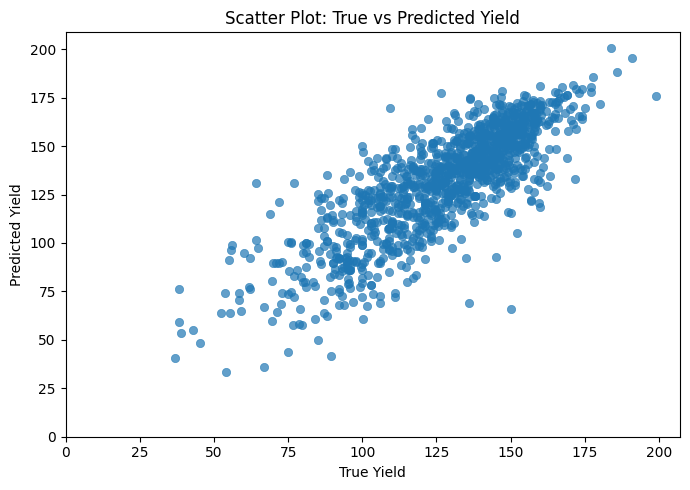

In [288]:
y_true = final_df_2000['yield'].values
y_pred = final_df_2000['orig_pred'].values

# Run report
performance_report(y_true, y_pred)

# Plot
# plt.figure(figsize=(7, 5))
# sns.scatterplot(x=y_true, y=y_pred, alpha=0.7, edgecolor=None)
# plt.xlabel("True Yield")
# plt.ylabel("Predicted Yield")
# plt.title("Scatter Plot: True vs Predicted Yield")
# plt.grid(True)
# plt.tight_layout()
# plt.show()

plt.figure(figsize=(7, 5))
sns.scatterplot(x=y_true, y=y_pred, alpha=0.7, edgecolor=None)
plt.xlabel("True Yield")
plt.ylabel("Predicted Yield")
plt.title("Scatter Plot: True vs Predicted Yield")
plt.xlim(0)  # Start x-axis at 0
plt.ylim(0)  # Start y-axis at 0
# plt.grid(True)
plt.tight_layout()
plt.show()

In [290]:
final_df_2000.to_csv("temp_2000.csv", index=False)

In [ ]:
################################################################
######## Bidirectional-LSTM with no attention 
################################################################

In [242]:
import torch.nn.functional as F

class BiLSTMModel_no_att(nn.Module):
    def __init__(self, input_dim, hidden_dim, layer_dim, fc_dims = [256, 64], output_dim=1, dropout = 0.0, use_cuda=False): 
        super(BiLSTMModel_no_att, self).__init__()
        self.name = 'LSTMModel_no_att'
        
        self.hidden_dim = hidden_dim
        self.layer_dim = layer_dim
        self.use_cuda = use_cuda

        self.lstm = nn.LSTM(input_dim, hidden_dim, layer_dim, batch_first=True, dropout=dropout, bidirectional=True)

        self.fc1 = nn.Linear(2 * hidden_dim, fc_dims[0])
        self.fc2 = nn.Linear(fc_dims[0], fc_dims[1])
        self.fc3 = nn.Linear(fc_dims[1], output_dim)

        self.bn1 = nn.BatchNorm1d(2 * hidden_dim)
        self.bn2 = nn.BatchNorm1d(fc_dims[0])
        self.bn3 = nn.BatchNorm1d(fc_dims[1])

    def forward(self, x):
        batch_size = x.size(0)  # Get current batch size

        # Initialize hidden state dynamically
        h0 = torch.zeros(2 * self.layer_dim, batch_size, self.hidden_dim).to(x.device)
        c0 = torch.zeros(2 * self.layer_dim, batch_size, self.hidden_dim).to(x.device)

        out, (hn, cn) = self.lstm(x, (h0, c0))  # Pass through LSTM
        state = torch.mean(out, dim=1)  # Reduce sequence dimension

        # Fully connected layers
        last_state = F.relu(state)
        last_state = F.relu(self.fc1(last_state))
        
        out = F.relu(self.fc2(last_state))
        out = self.fc3(out)

        return out

In [243]:
def performance_report(y_true, y_pred):
    r_square = r2_score(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r = pearsonr(y_true.flatten(), y_pred.flatten())[0]

    print('---------------')
    print(f'r_square: {r_square:.4f}')
    print(f'rmse: {rmse:.4f}')
    print(f'Pearson r: {r:.4f}')
    print(f'Pearson r^2: {r**2:.4f}')
    print(f'y_true mean: {y_true.mean():.4f}, y_pred mean: {y_pred.mean():.4f}')

def train_test_split_by_year_sequence(X, y_df, test_year):
    train_index = y_df['year'] < test_year
    test_index = y_df['year'] == test_year

    X_train, y_train = X[train_index], y_df[train_index]
    X_test, y_test = X[test_index], y_df[test_index]

    return X_train, y_train, X_test, y_test

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# --- Load Data ---
# X_day_tensor = torch.tensor(X_day, dtype=torch.float32)
# X_day_tensor = X_day_tensor.reshape(-1, 19, 210)
# X_day_tensor = X_day_tensor.permute(0, 2, 1).float()

# X_day_tensor = torch.tensor(X_day, dtype=torch.float32).reshape(-1, 19, 210)
# X_day_tensor = X_day_tensor.permute(0, 2, 1).to(device)  
# y_tensor = torch.tensor(y_df['yield'], dtype=torch.float32).to(device)

batch_size = 256
all_years = np.arange(2000, 2019)  
y_df = county_detrend_func(y_df, None, all_years)  


model = BiLSTMModel_no_att(input_dim = 19, hidden_dim = 64, layer_dim = 2, use_cuda = torch.cuda.is_available()).to(device)
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
num_epochs = 200

for year in all_years:
    print(f"\nTest Year: {year}")
    
    X_train, y_train, X_test, y_test = train_test_split_by_year_sequence(X_day, y_df, year)

    # Convert to tensors
    X_train_tensor = torch.tensor(X_train, dtype = torch.float32).to(device)
    X_train_tensor = X_train_tensor.reshape(-1, 19, 210)
    X_train_tensor = X_train_tensor.permute(0, 2, 1).float()

    y_train_tensor = torch.tensor(y_train['detrend'].values, dtype=torch.float32).unsqueeze(1).to(device)  
    
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
    X_test_tensor = X_test_tensor.reshape(-1, 19, 210)
    X_test_tensor = X_test_tensor.permute(0, 2, 1).float()
    
    y_test_tensor = torch.tensor(y_test['detrend'].values, dtype=torch.float32).unsqueeze(1).to(device)

    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = DataLoader(train_dataset, batch_size = batch_size, shuffle=True)

    # Training Loop
    for epoch in range(num_epochs):
        model.train()  
        epoch_loss = 0.0  # Track loss

        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()  
            
            preds = model(X_batch)  
            loss = loss_fn(preds, y_batch)  
            loss.backward()  
            
            optimizer.step()  
            epoch_loss += loss.item()

        if (epoch + 1) % 5 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss / len(train_loader):.4f}')

    model.eval()  
    with torch.no_grad():
        y_pred = model(X_test_tensor)

    y_true_np = y_test_tensor.cpu().numpy()
    y_pred_np = y_pred.cpu().numpy()

    y_df.loc[y_df['year'] == year, 'pred'] = y_pred_np.flatten()

    print(f"\nPerformance Report for Year {year}:")
    performance_report(y_true_np, y_pred_np)

print("\nTraining completed for all years.")

Using device: cpu


/var/folders/xw/pk8h6grn7k3f0d_vdm1wntmw0000gs/T/ipykernel_72502/870329699.py:23: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'True' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  y_df.loc[y_df['id2'] == id, 'county_detrend_flag'] = True



Test Year: 2000
Epoch [5/200], Loss: 157.6265
Epoch [10/200], Loss: 124.7819
Epoch [15/200], Loss: 115.9404
Epoch [20/200], Loss: 102.7811
Epoch [25/200], Loss: 93.6279
Epoch [30/200], Loss: 86.5238
Epoch [35/200], Loss: 85.2052
Epoch [40/200], Loss: 82.8002



KeyboardInterrupt



In [150]:
# loss_fn = nn.MSELoss()
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# # Move data to the appropriate device
# X_ave_tensor = torch.tensor(X, dtype = torch.float32).to(device)
# y_tensor = torch.tensor(y_df['yield'], dtype = torch.float32).to(device)
# ### input structure should be -- (batch_size, sequence_length, input_dim)

# # Load model
# model = LSTMModel_no_att(input_dim = 210, hidden_dim = 64, layer_dim=2, use_cuda=torch.cuda.is_available())
# model.to(device)

# optimizer = optim.Adam(model.parameters(), lr=0.001)  # Adam optimizer with learning rate 0.001
# num_epochs = 200  # Number of iterations to train

# # Training loop
# for epoch in range(num_epochs):
#     model.train()  # Set model to training mode   
#     optimizer.zero_grad()  # Reset gradients
#     predictions = model(X_ave_tensor)  # Forward pass
#     loss = loss_fn(predictions, y_tensor)  # Compute loss
#     loss.backward()  # Backpropagation
#     optimizer.step()  # Update model weights
    
#     # Print progress (verbose output)
#     if (epoch + 1) % 5 == 0:  # Show loss every 5 epochs
#         print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

# # Switch to evaluation mode
# model.eval()
# with torch.no_grad():
#     final_predictions = model(X_ave_tensor)

# predictions_numpy = final_predictions.cpu().numpy()  # Convert to NumPy for further analysis

In [ ]:
y_true_np = y_tensor.cpu().numpy()
y_pred_np = final_predictions.cpu().numpy()

performance_report(y_true_np, y_pred_np)

In [ ]:
################################################################
######## LSTM with attention -- modified from original
################################################################

In [161]:
class Attention(nn.Module):
    def __init__(self, hidden_dim):
        super(Attention, self).__init__()
        self.attn = nn.Linear(hidden_dim, 1)  # Linear layer to compute attention scores
    
    def forward(self, lstm_out):
        # lstm_out shape: (batch_size, seq_len, hidden_dim)
        attn_scores = self.attn(lstm_out).squeeze(-1)  # (batch_size, seq_len)
        attn_weights = F.softmax(attn_scores, dim=1)  # Normalize scores
        context = torch.sum(lstm_out * attn_weights.unsqueeze(-1), dim=1)  # Weighted sum
        return context

class LSTMModel_with_att(nn.Module):
    def __init__(self, input_dim, hidden_dim, layer_dim, fc_dims=[256, 64], output_dim=1, dropout=0.0, use_cuda=False):
        super(LSTMModel_with_att, self).__init__()
        self.name = 'LSTMModel_with_att'
        
        self.hidden_dim = hidden_dim
        self.layer_dim = layer_dim
        self.use_cuda = use_cuda

        # LSTM Layer
        self.lstm = nn.LSTM(input_dim, hidden_dim, layer_dim, batch_first=True, dropout=dropout)
        
        # Attention Layer
        self.attention = Attention(hidden_dim)

        # Fully Connected Layers
        self.fc1 = nn.Linear(hidden_dim, fc_dims[0])
        self.fc2 = nn.Linear(fc_dims[0], fc_dims[1])
        self.fc3 = nn.Linear(fc_dims[1], output_dim)

    def forward(self, input):
        # input shape: (batch_size, sequence_length, input_dim)
        x = input.reshape(-1, 19, 210)
        x = x.permute(0, 2, 1).float()
        
        # Initialize hidden and cell state
        h0 = torch.zeros(self.layer_dim, input.size(0), self.hidden_dim).requires_grad_()
        c0 = torch.zeros(self.layer_dim, input.size(0), self.hidden_dim).requires_grad_()

        if self.use_cuda:
            h0, c0 = h0.cuda(), c0.cuda()
            input = input.cuda()

        # LSTM forward pass
        out, (hn, cn) = self.lstm(input, (h0.detach(), c0.detach()))
        
        # Apply attention
        context = self.attention(out)  # (batch_size, hidden_dim)
        
        # Fully connected layers
        out = F.relu(self.fc1(context))
        out = F.relu(self.fc2(out))
        out = self.fc3(out)
        
        return out

In [163]:
def train_test_split_by_year(X, y_df, test_year, X_extra = None):
    train_index = y_df['year'] != test_year
    test_index = y_df['year'] == test_year

    X_train, y_train = X[train_index], y_df[train_index]
    X_test, y_test = X[test_index], y_df[test_index]

    if X_extra is not None:
        X_extra_train = X_extra[train_index]
        X_extra_test = X_extra[test_index]
        return X_train, y_train, X_test, y_test, X_extra_train, X_extra_test
    return X_train, y_train, X_test, y_test

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = LSTMModel_no_att(input_dim = 210, hidden_dim = 64, layer_dim = 2, use_cuda = torch.cuda.is_available()).to(device)
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
num_epochs = 200

all_years = np.array(list(range(2000, 2019)))
y_df = county_detrend_func(y_df, None, all_years)

for year in all_years:
    print(f"\nTest Year: {year}")
    
    X_train, y_train, X_test, y_test = train_test_split_by_year(X_ave, y_df, year)

    # print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

    X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
    y_train_tensor = torch.tensor(y_train['detrend'].values, dtype=torch.float32).unsqueeze(1).to(device)  # Ensure correct shape
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
    y_test_tensor = torch.tensor(y_test['detrend'].values, dtype=torch.float32).unsqueeze(1).to(device)

    # Training loop
    for epoch in range(num_epochs):
        model.train()  # Set model to training mode   
        optimizer.zero_grad()  # Reset gradients
        predictions = model(X_train_tensor)  # Forward pass
        loss = loss_fn(predictions, y_train_tensor)  # Compute loss
        loss.backward()  # Backpropagation
        optimizer.step()  # Update model weights

        # Print progress
        if (epoch + 1) % 5 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

    model.eval()    
    with torch.no_grad():
        y_pred = model(X_test_tensor)

    y_true_np = y_test_tensor.cpu().numpy()
    y_pred_np = y_pred.cpu().numpy()

    y_df.loc[y_df['year'] == year, 'pred'] = y_pred_np.flatten()

    print(f"\nPerformance Report for Year {year}:")
    performance_report(y_true_np, y_pred_np)
    
print("\nTraining completed for all years.")

/var/folders/xw/pk8h6grn7k3f0d_vdm1wntmw0000gs/T/ipykernel_72502/3887481669.py:19: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'True' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  y_df.loc[y_df['id2'] == id, 'county_detrend_flag'] = True



Test Year: 2000
Epoch [5/200], Loss: 423.0533
Epoch [10/200], Loss: 422.6573
Epoch [15/200], Loss: 421.1592
Epoch [20/200], Loss: 415.8011
Epoch [25/200], Loss: 399.5454
Epoch [30/200], Loss: 373.9521
Epoch [35/200], Loss: 339.3144
Epoch [40/200], Loss: 306.2400
Epoch [45/200], Loss: 275.0164
Epoch [50/200], Loss: 243.7846
Epoch [55/200], Loss: 219.4669
Epoch [60/200], Loss: 201.2484
Epoch [65/200], Loss: 192.0567
Epoch [70/200], Loss: 182.0854
Epoch [75/200], Loss: 174.2821
Epoch [80/200], Loss: 166.1258
Epoch [85/200], Loss: 159.6656
Epoch [90/200], Loss: 155.3992
Epoch [95/200], Loss: 149.1152
Epoch [100/200], Loss: 144.1213
Epoch [105/200], Loss: 140.1703
Epoch [110/200], Loss: 150.7230
Epoch [115/200], Loss: 153.6263
Epoch [120/200], Loss: 141.0535
Epoch [125/200], Loss: 133.1201
Epoch [130/200], Loss: 133.9189
Epoch [135/200], Loss: 131.2620
Epoch [140/200], Loss: 128.2115
Epoch [145/200], Loss: 127.2469
Epoch [150/200], Loss: 125.3413
Epoch [155/200], Loss: 123.5674
Epoch [160/

In [152]:
X_ave_tensor = X_ave_tensor.permute(0, 2, 1).float()
X_ave_tensor.shape

torch.Size([45338, 210, 19])

In [ ]:
################################################################
######## LSTM with attention (historical data --> current-year prediction)
################################################################

In [252]:
class Attention(nn.Module):
    def __init__(self, hidden_dim):
        super(Attention, self).__init__()
        self.attn = nn.Linear(hidden_dim, 1)  # Linear layer to compute attention scores
    
    def forward(self, lstm_out):
        # lstm_out shape: (batch_size, seq_len, hidden_dim)
        attn_scores = self.attn(lstm_out).squeeze(-1)  # (batch_size, seq_len)
        attn_weights = F.softmax(attn_scores, dim=1)  # Normalize scores
        context = torch.sum(lstm_out * attn_weights.unsqueeze(-1), dim=1)  # Weighted sum
        return context

class LSTMModel_with_att(nn.Module):
    def __init__(self, input_dim, hidden_dim, layer_dim, fc_dims=[256, 64], output_dim=1, dropout=0.0, use_cuda=False):
        super(LSTMModel_with_att, self).__init__()
        self.name = 'LSTMModel_with_att'
        
        self.hidden_dim = hidden_dim
        self.layer_dim = layer_dim
        self.use_cuda = use_cuda

        # LSTM Layer
        self.lstm = nn.LSTM(input_dim, hidden_dim, layer_dim, batch_first=True, dropout=dropout)
        
        # Attention Layer
        self.attention = Attention(hidden_dim)

        # Fully Connected Layers
        self.fc1 = nn.Linear(hidden_dim, fc_dims[0])
        self.fc2 = nn.Linear(fc_dims[0], fc_dims[1])
        self.fc3 = nn.Linear(fc_dims[1], output_dim)

    def forward(self, x):
        batch_size = x.size(0)
        
        # Initialize hidden and cell state
        h0 = torch.zeros(self.layer_dim, batch_size, self.hidden_dim).requires_grad_()
        c0 = torch.zeros(self.layer_dim, batch_size, self.hidden_dim).requires_grad_()

        if self.use_cuda:
            h0, c0 = h0.cuda(), c0.cuda()
            x = x.cuda()

        # LSTM forward pass
        out, (hn, cn) = self.lstm(x, (h0.detach(), c0.detach()))
    
        # print("Intermediate output:", out.shape)
        
        # Apply attention
        context = self.attention(out)  
        
        # Fully connected layers
        out = F.relu(self.fc1(context))
        out = F.relu(self.fc2(out))
        out = self.fc3(out)
        
        return out

In [254]:
def performance_report(y_true, y_pred):
    r_square = r2_score(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r = pearsonr(y_true.flatten(), y_pred.flatten())[0]

    print('---------------')
    print(f'r_square: {r_square:.4f}')
    print(f'rmse: {rmse:.4f}')
    print(f'Pearson r: {r:.4f}')
    print(f'Pearson r^2: {r**2:.4f}')
    print(f'y_true mean: {y_true.mean():.4f}, y_pred mean: {y_pred.mean():.4f}')

def train_test_split_by_year_sequence(X, y_df, test_year):
    train_index = y_df['year'] < test_year
    test_index = y_df['year'] == test_year

    X_train, y_train = X[train_index], y_df[train_index]
    X_test, y_test = X[test_index], y_df[test_index]

    return X_train, y_train, X_test, y_test

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

batch_size = 256
all_years = np.arange(2000, 2019)  
y_df = county_detrend_func(y_df, None, all_years)  


model = LSTMModel_with_att(input_dim = 19, hidden_dim = 64, layer_dim = 2, use_cuda = torch.cuda.is_available()).to(device)
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
num_epochs = 200

for year in all_years:
    print(f"\nTest Year: {year}")
    
    X_train, y_train, X_test, y_test = train_test_split_by_year_sequence(X_day, y_df, year)

    # Convert to tensors
    X_train_tensor = torch.tensor(X_train, dtype = torch.float32).to(device)
    X_train_tensor = X_train_tensor.reshape(-1, 19, 210)
    X_train_tensor = X_train_tensor.permute(0, 2, 1).float()

    y_train_tensor = torch.tensor(y_train['detrend'].values, dtype=torch.float32).unsqueeze(1).to(device)  
    
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
    X_test_tensor = X_test_tensor.reshape(-1, 19, 210)
    X_test_tensor = X_test_tensor.permute(0, 2, 1).float()
    
    y_test_tensor = torch.tensor(y_test['detrend'].values, dtype=torch.float32).unsqueeze(1).to(device)

    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = DataLoader(train_dataset, batch_size = batch_size, shuffle=True)

    # Training Loop
    for epoch in range(num_epochs):
        model.train()  
        epoch_loss = 0.0  # Track loss

        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()  
            
            preds = model(X_batch)  
            loss = loss_fn(preds, y_batch)  
            loss.backward()  
            
            optimizer.step()  
            epoch_loss += loss.item()

        if (epoch + 1) % 5 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss / len(train_loader):.4f}')

    model.eval()  
    with torch.no_grad():
        y_pred = model(X_test_tensor)

    y_true_np = y_test_tensor.cpu().numpy()
    y_pred_np = y_pred.cpu().numpy()

    y_df.loc[y_df['year'] == year, 'pred'] = y_pred_np.flatten()

    print(f"\nPerformance Report for Year {year}:")
    performance_report(y_true_np, y_pred_np)

print("\nTraining completed for all years.")

In [ ]:
################################################################
######## BiLSTM with attention (historical data --> current-year prediction)
################################################################

In [257]:
class Attention(nn.Module):
    def __init__(self, hidden_dim):
        super(Attention, self).__init__()
        self.attn = nn.Linear(hidden_dim, 1)  # Linear layer to compute attention scores
    
    def forward(self, lstm_out):
        # lstm_out shape: (batch_size, seq_len, hidden_dim)
        attn_scores = self.attn(lstm_out).squeeze(-1)  # (batch_size, seq_len)
        attn_weights = F.softmax(attn_scores, dim=1)  # Normalize scores
        context = torch.sum(lstm_out * attn_weights.unsqueeze(-1), dim=1)  # Weighted sum
        return context

class BiLSTMModel_with_att(nn.Module):
    def __init__(self, input_dim, hidden_dim, layer_dim, fc_dims=[256, 64], output_dim=1, dropout=0.0, use_cuda=False):
        super(BiLSTMModel_with_att, self).__init__()
        self.name = 'BiLSTMModel_with_att'
        
        self.hidden_dim = hidden_dim
        self.layer_dim = layer_dim
        self.use_cuda = use_cuda

        # LSTM Layer
        self.lstm = nn.LSTM(input_dim, hidden_dim, layer_dim, batch_first=True, dropout=dropout, bidirectional=True)
        
        # Attention Layer
        self.attention = Attention(2*hidden_dim)

        # Fully Connected Layers
        self.fc1 = nn.Linear(2*hidden_dim, fc_dims[0])
        self.fc2 = nn.Linear(fc_dims[0], fc_dims[1])
        self.fc3 = nn.Linear(fc_dims[1], output_dim)

    def forward(self, x):
        batch_size = x.size(0)
        
        # Initialize hidden and cell state
        h0 = torch.zeros(2*self.layer_dim, batch_size, self.hidden_dim).requires_grad_()
        c0 = torch.zeros(2*self.layer_dim, batch_size, self.hidden_dim).requires_grad_()

        if self.use_cuda:
            h0, c0 = h0.cuda(), c0.cuda()
            x = x.cuda()

        # LSTM forward pass
        out, (hn, cn) = self.lstm(x, (h0.detach(), c0.detach()))
    
        # print("Intermediate output:", out.shape)
        
        # Apply attention
        context = self.attention(out)  
        
        # Fully connected layers
        out = F.relu(self.fc1(context))
        out = F.relu(self.fc2(out))
        out = self.fc3(out)
        
        return out

In [258]:
def performance_report(y_true, y_pred):
    r_square = r2_score(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r = pearsonr(y_true.flatten(), y_pred.flatten())[0]

    print('---------------')
    print(f'r_square: {r_square:.4f}')
    print(f'rmse: {rmse:.4f}')
    print(f'Pearson r: {r:.4f}')
    print(f'Pearson r^2: {r**2:.4f}')
    print(f'y_true mean: {y_true.mean():.4f}, y_pred mean: {y_pred.mean():.4f}')

def train_test_split_by_year_sequence(X, y_df, test_year):
    train_index = y_df['year'] < test_year
    test_index = y_df['year'] == test_year

    X_train, y_train = X[train_index], y_df[train_index]
    X_test, y_test = X[test_index], y_df[test_index]

    return X_train, y_train, X_test, y_test

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

batch_size = 256
all_years = np.arange(2000, 2019)  
y_df = county_detrend_func(y_df, None, all_years)  


model = BiLSTMModel_with_att(input_dim = 19, hidden_dim = 64, layer_dim = 2, use_cuda = torch.cuda.is_available()).to(device)
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
num_epochs = 200

for year in all_years:
    print(f"\nTest Year: {year}")
    
    X_train, y_train, X_test, y_test = train_test_split_by_year_sequence(X_day, y_df, year)

    # Convert to tensors
    X_train_tensor = torch.tensor(X_train, dtype = torch.float32).to(device)
    X_train_tensor = X_train_tensor.reshape(-1, 19, 210)
    X_train_tensor = X_train_tensor.permute(0, 2, 1).float()

    y_train_tensor = torch.tensor(y_train['detrend'].values, dtype=torch.float32).unsqueeze(1).to(device)  
    
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
    X_test_tensor = X_test_tensor.reshape(-1, 19, 210)
    X_test_tensor = X_test_tensor.permute(0, 2, 1).float()
    
    y_test_tensor = torch.tensor(y_test['detrend'].values, dtype=torch.float32).unsqueeze(1).to(device)

    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = DataLoader(train_dataset, batch_size = batch_size, shuffle=True)

    # Training Loop
    for epoch in range(num_epochs):
        model.train()  
        epoch_loss = 0.0  # Track loss

        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()  
            
            preds = model(X_batch)  
            loss = loss_fn(preds, y_batch)  
            loss.backward()  
            
            optimizer.step()  
            epoch_loss += loss.item()

        if (epoch + 1) % 5 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss / len(train_loader):.4f}')

    model.eval()  
    with torch.no_grad():
        y_pred = model(X_test_tensor)

    y_true_np = y_test_tensor.cpu().numpy()
    y_pred_np = y_pred.cpu().numpy()

    y_df.loc[y_df['year'] == year, 'pred'] = y_pred_np.flatten()

    print(f"\nPerformance Report for Year {year}:")
    performance_report(y_true_np, y_pred_np)

print("\nTraining completed for all years.")

Using device: cpu


/var/folders/xw/pk8h6grn7k3f0d_vdm1wntmw0000gs/T/ipykernel_72502/870329699.py:23: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'True' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  y_df.loc[y_df['id2'] == id, 'county_detrend_flag'] = True



Test Year: 2000
Epoch [5/200], Loss: 145.2072
Epoch [10/200], Loss: 112.2903
Epoch [15/200], Loss: 99.5667
Epoch [20/200], Loss: 90.4499
Epoch [25/200], Loss: 82.3220


KeyboardInterrupt: 

In [ ]:
### lstm_attn()
# r_square: 0.7698
# rmse: 8.8379
# r: .8861

In [ ]:
##############################################
######### Time-series Transformers 
##############################################

In [38]:
class SelfAttentionModel(nn.Module):
    def __init__(self, input_dim, d_model, num_heads, num_time_steps):
        super(SelfAttentionModel, self).__init__()
        self.d_model = d_model
        self.num_heads = num_heads
        self.num_time_steps = num_time_steps
        self.embedding = nn.Linear(input_dim, d_model)
        self.positional_encoding = self._create_positional_encoding(num_time_steps, d_model)
        self.self_attention = nn.MultiheadAttention(d_model, num_heads, batch_first=True)
        self.linear = nn.Linear(d_model, 1) # Output is a single target value
        # 'hidden_dim' is currently unused

    def _create_positional_encoding(self, seq_len, d_model):
        pos = torch.arange(0, seq_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * -(np.log(10000.0) / d_model))
        pe = torch.zeros(seq_len, 1, d_model)
        pe[:, 0, 0::2] = torch.sin(pos * div_term)
        pe[:, 0, 1::2] = torch.cos(pos * div_term)
        return pe # Shape: (seq_len, 1, d_model)

    def forward(self, x):
        # x shape: (batch_size, seq_len=num_time_steps, input_dim=19)
        embedded = self.embedding(x) # shape: (batch_size, num_time_steps, d_model)
        position_encoded = embedded + self.positional_encoding.squeeze(1).unsqueeze(0).to(x.device) # shape: (batch_size, num_time_steps, d_model)
        attn_output, _ = self.self_attention(position_encoded, position_encoded, position_encoded) # shape: (batch_size, num_time_steps, d_model)

        # Using the last context vector
        last_context_vector = attn_output[:, -1, :] # shape: (batch_size, d_model)
        prediction = self.linear(last_context_vector) # shape: (batch_size, 1)

        return prediction

In [42]:
from statsmodels.nonparametric.smoothers_lowess import lowess

def performance_report(y_true, y_pred):
    r_square = r2_score(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r = pearsonr(y_true.flatten(), y_pred.flatten())[0]

    print('---------------')
    print(f'r_square: {r_square:.4f}')
    print(f'rmse: {rmse:.4f}')
    print(f'Pearson r: {r:.4f}')
    print(f'Pearson r^2: {r**2:.4f}')
    print(f'y_true mean: {y_true.mean():.4f}, y_pred mean: {y_pred.mean():.4f}')

def train_test_split_by_year_sequence(X, y_df, test_year, seed=42):
    train_index = y_df['year'] < test_year
    test_index = y_df['year'] == test_year

    np.random.seed(seed)
    valid_train_years = y_df['year'].unique()
    valid_train_years = valid_train_years[valid_train_years < (test_year - 1)]
    random_year = np.random.choice(valid_train_years)

    val_index = y_df['year'] == random_year

    X_train, y_train = X[train_index], y_df[train_index]
    X_test, y_test = X[test_index], y_df[test_index]
    X_val, y_val = X[val_index], y_df[val_index]

    return X_train, y_train, X_test, y_test, X_val, y_val

def county_detrend_func_loess(y_df, test_year, all_years, record_count_threshold=1, frac=0.3):
    y_df = y_df.copy()
    y_df['trend'] = np.nan
    y_df['detrend'] = np.nan
    y_df['county_detrend_flag'] = np.nan

    unique_county_ids = y_df['id2'].unique()

    for id in unique_county_ids:
        county_df = y_df[y_df['id2'] == id].copy()
        county_df = county_df.sort_values('year')

        X = county_df['year'].values
        y = county_df['yield'].values

        if county_df.shape[0] < record_count_threshold:
            y_df.loc[y_df['id2'] == id, 'county_detrend_flag'] = False
            continue  # Skip LOESS detrending for small data
        else:
            y_df.loc[y_df['id2'] == id, 'county_detrend_flag'] = True

        # Apply LOWESS smoothing
        lowess_result = lowess(endog=y, exog=X, frac=frac, it=0, return_sorted=False)

        # Update the dataframe with trend and detrended values
        y_df.loc[y_df['id2'] == id, 'trend'] = lowess_result
        y_df.loc[y_df['id2'] == id, 'detrend'] = y - lowess_result

    return y_df


def main():
    y_df = pd.read_csv('/Users/guptsh/Downloads/Soil_Land_Crop/datasets/gridMET_data/modified/label.csv')
    y_df['pred'] = np.nan

    contents = ['tmmn', 'tmmx', 'pr', 'srad', 'sph', 'rmin', 'rmax', 'vs', 'th',  # 9 main
                'vpd', 'pet', 'etr', 'erc', 'bi', 'fm100', 'fm1000']  # except pdsi so far
    X = wr.read_feature_data(contents)

    ##### When using norm = "std"
    X, wind_zero_idx = wr.feature_engineering(X, contents, norm = "std", intersect = False)
    N, feature_num = X.shape[0], X.shape[1]

    ### daily
    X_dcpy = X.copy()
    X_day = X_dcpy.reshape((N, -1))
    
    num_time_steps = 210
    features_per_step = 19
    d_model = 32

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    batch_size = 64 ##256
    all_years = np.arange(2000, 2006)  
    # y_df = wr.county_detrend_func(y_df, None, all_years)
    y_df = county_detrend_func_loess(y_df, None, all_years)  


    for year in all_years:
        print(f"\nTest Year: {year}")
        
        X_train, y_train, X_test, y_test, X_val, y_val = train_test_split_by_year_sequence(X_day, y_df, year)

        # Convert to tensors
        X_train_tensor = torch.tensor(X_train, dtype = torch.float32).to(device)
        X_train_tensor = X_train_tensor.reshape(-1, 19, 210)
        X_train_tensor = X_train_tensor.permute(0, 2, 1).float()

        y_train_tensor = torch.tensor(y_train['detrend'].values, dtype=torch.float32).unsqueeze(1).to(device)  
        
        X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
        X_test_tensor = X_test_tensor.reshape(-1, 19, 210)
        X_test_tensor = X_test_tensor.permute(0, 2, 1).float()
        
        y_test_tensor = torch.tensor(y_test['detrend'].values, dtype=torch.float32).unsqueeze(1).to(device)

        X_val_tensor = torch.tensor(X_val, dtype=torch.float32).to(device)
        X_val_tensor = X_val_tensor.reshape(-1, 19, 210)
        X_val_tensor = X_val_tensor.permute(0, 2, 1).float()
        
        y_val_tensor = torch.tensor(y_val['detrend'].values, dtype=torch.float32).unsqueeze(1).to(device)

        train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
        train_loader = DataLoader(train_dataset, batch_size = batch_size, shuffle=True)

        # model = LSTMModel_no_att(input_dim = 19, hidden_dim = 64, layer_dim = 2, use_cuda = torch.cuda.is_available()).to(device)
        
        model = SelfAttentionModel(input_dim=features_per_step, d_model=d_model, num_heads=1, num_time_steps=num_time_steps).to(device)
        loss_fn = nn.MSELoss()
        optimizer = optim.Adam(model.parameters(), lr = 0.001)
        num_epochs = 40

        # Training Loop
        for epoch in range(num_epochs):
            model.train()  
            train_loss = 0.0  # Track loss

            for X_batch, y_batch in train_loader:
                optimizer.zero_grad()  
                
                preds = model(X_batch)
                loss = loss_fn(preds, y_batch)  
                loss.backward()  
                
                optimizer.step()  
                train_loss += loss.item()
            
            # Compute training loss per batch
            train_loss /= len(train_loader)
    
            # --- Validation Step ---
            model.eval()
            with torch.no_grad():
                val_preds = model(X_val_tensor)
                val_loss = loss_fn(val_preds, y_val_tensor).item()
    
            # Print both training and validation loss
            if (epoch + 1) % 5 == 0:
                print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {train_loss:.4f}, Validation Loss: {val_loss:.4f}")

        model.eval()  
        with torch.no_grad():
            y_pred = model(X_test_tensor)

        y_true_np = y_test_tensor.cpu().numpy()
        y_pred_np = y_pred.cpu().numpy()

        y_df.loc[y_df['year'] == year, 'pred'] = y_pred_np.flatten()

        ## adding trend back to the prediction
        mask = y_df['year'] == year
        y_df.loc[mask, 'orig_pred'] = y_df.loc[mask, 'pred'] + y_df.loc[mask, 'trend']
        # y_df[['year'] == year, 'orig_pred'] = y_df[['year'] == year, 'pred'] + y_df[['year'] == year, 'trend']

        print(f"\nPerformance Report for Year {year}:")
        # performance_report(y_true_np, y_pred_np)
        performance_report(y_df.loc[mask, 'orig_pred'].values, y_df.loc[mask, 'yield'].values)

    print("\nTraining completed for all years.")

    test_years = list(range(2000, 2006)) 
    final_df = y_df[y_df['year'].isin(test_years) & y_df['pred'].notna()]

    # y_true_all = final_df['detrend'].values
    # y_pred_all = final_df['pred'].values

    y_true_all = final_df['yield'].values
    y_pred_all = final_df['orig_pred'].values

    print("\n=== Overall Performance Report for 2000 to 2019 ===")
    performance_report(y_true_all, y_pred_all)

    # final_df.to_csv("plots_data/lstm_no_attn_2000_2005_detrend_loess.csv", index=False)

    plt.figure(figsize=(7, 5))
    sns.scatterplot(x = y_true_all, y = y_pred_all, alpha=0.7, edgecolor=None)
    plt.xlabel("True Yield")
    plt.ylabel("Predicted Yield")
    plt.title("Scatter Plot: True vs Predicted Yield")
    plt.xlim(0)
    plt.ylim(0)
    plt.tight_layout()

    # Save the figure before showing it
    # plt.savefig("plots_data/lstm_no_attn_2000_2005_detrend_loess.png")  


if __name__ == "__main__":
    main()

pre-shape (45338, 210)
post-shape (1, 45338, 210)
pre-shape (45338, 210)
post-shape (1, 45338, 210)
pre-shape (45338, 210)
post-shape (1, 45338, 210)
pre-shape (45338, 210)
post-shape (1, 45338, 210)
pre-shape (45338, 210)
post-shape (1, 45338, 210)
pre-shape (45338, 210)
post-shape (1, 45338, 210)
pre-shape (45338, 210)
post-shape (1, 45338, 210)
pre-shape (45338, 210)
post-shape (1, 45338, 210)
pre-shape (45338, 210)
post-shape (1, 45338, 210)
pre-shape (45338, 210)
post-shape (1, 45338, 210)
pre-shape (45338, 210)
post-shape (1, 45338, 210)
pre-shape (45338, 210)
post-shape (1, 45338, 210)
pre-shape (45338, 210)
post-shape (1, 45338, 210)
pre-shape (45338, 210)
post-shape (1, 45338, 210)
pre-shape (45338, 210)
post-shape (1, 45338, 210)
pre-shape (45338, 210)
post-shape (1, 45338, 210)
vs idx is 7
(45338, 19, 210)
Using device: cpu


/var/folders/xw/pk8h6grn7k3f0d_vdm1wntmw0000gs/T/ipykernel_51045/3448425369.py:52: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'True' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  y_df.loc[y_df['id2'] == id, 'county_detrend_flag'] = True
/Users/guptsh/shrey_env/lib/python3.13/site-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),
/Users/guptsh/shrey_env/lib/python3.13/site-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),
/Users/guptsh/shrey_env/lib/python3.13/site-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),
/Users/guptsh/shrey_env/lib/py


Test Year: 2000
Epoch [5/40] - Train Loss: 187.7758, Validation Loss: 175.7626
Epoch [10/40] - Train Loss: 170.2995, Validation Loss: 138.3997
Epoch [15/40] - Train Loss: 164.3334, Validation Loss: 120.3096
Epoch [20/40] - Train Loss: 155.4891, Validation Loss: 111.2859
Epoch [25/40] - Train Loss: 158.2566, Validation Loss: 111.8574
Epoch [30/40] - Train Loss: 153.5969, Validation Loss: 106.3586
Epoch [35/40] - Train Loss: 145.8626, Validation Loss: 104.3196
Epoch [40/40] - Train Loss: 139.2605, Validation Loss: 100.6186

Performance Report for Year 2000:
---------------
r_square: 0.6022
rmse: 18.2232
Pearson r: 0.7816
Pearson r^2: 0.6109
y_true mean: 127.2071, y_pred mean: 127.3818

Test Year: 2001
Epoch [5/40] - Train Loss: 171.7645, Validation Loss: 120.9190
Epoch [10/40] - Train Loss: 159.9300, Validation Loss: 115.8824
Epoch [15/40] - Train Loss: 157.0936, Validation Loss: 120.2482
Epoch [20/40] - Train Loss: 143.7552, Validation Loss: 114.0366
Epoch [25/40] - Train Loss: 143.218

KeyboardInterrupt: 